In [15]:
import h5py
import matplotlib.pyplot as plt
import numpy as np
import torch

def visualize_h5_clips(h5_path, num_clips=2):
    """
    Visualize raw clips from the H5 file showing the teacher (global) and student (local) views.
    
    Args:
        h5_path: Path to the H5 file
        num_clips: Number of clips to visualize
    """
    with h5py.File(h5_path, 'r') as f:
        total_clips = len(f.keys())
        print(f"Total number of clips in dataset: {total_clips}")
        
        # Visualize specified number of random clips
        clip_indices = np.random.choice(total_clips, num_clips, replace=False)
        clip_indices = [13000, 13001]
        
        for clip_idx in clip_indices:
            clip_group = f[str(clip_idx)]
            num_views = len(clip_group.keys())
            
            # Create a figure with subplots for each frame in the clip
            num_frames = clip_group['0'].shape[0]  # number of frames in teacher view
            fig, axes = plt.subplots(num_views, num_frames, 
                                   figsize=(3*num_frames, 3*num_views))
            fig.suptitle(f'Clip {clip_idx} - All Views and Frames')
            
            # Plot each view
            for view_idx in range(num_views):
                frames = torch.from_numpy(clip_group[str(view_idx)][()])
                
                # Plot each frame in the view
                for frame_idx in range(num_frames):
                    ax = axes[view_idx, frame_idx] if num_views > 1 else axes[frame_idx]
                    frame = frames[frame_idx].permute(1, 2, 0)
                    ax.imshow(frame.clip(0, 1))  # Clip values to [0,1] for visualization
                    ax.axis('off')

                    # Get frame dimensions
                    height, width, _ = frame.shape
                    ax.text(5, 15, f'{width}x{height}', color='white', fontsize=12,
                            bbox=dict(facecolor='black', alpha=0.5, edgecolor='none'))
                    
                    if frame_idx == 0:
                        ax.set_title(f'View {view_idx}\n{"Teacher" if view_idx == 0 else "Student"}')
            
            plt.tight_layout()
            plt.show()


Total number of clips in dataset: 20970


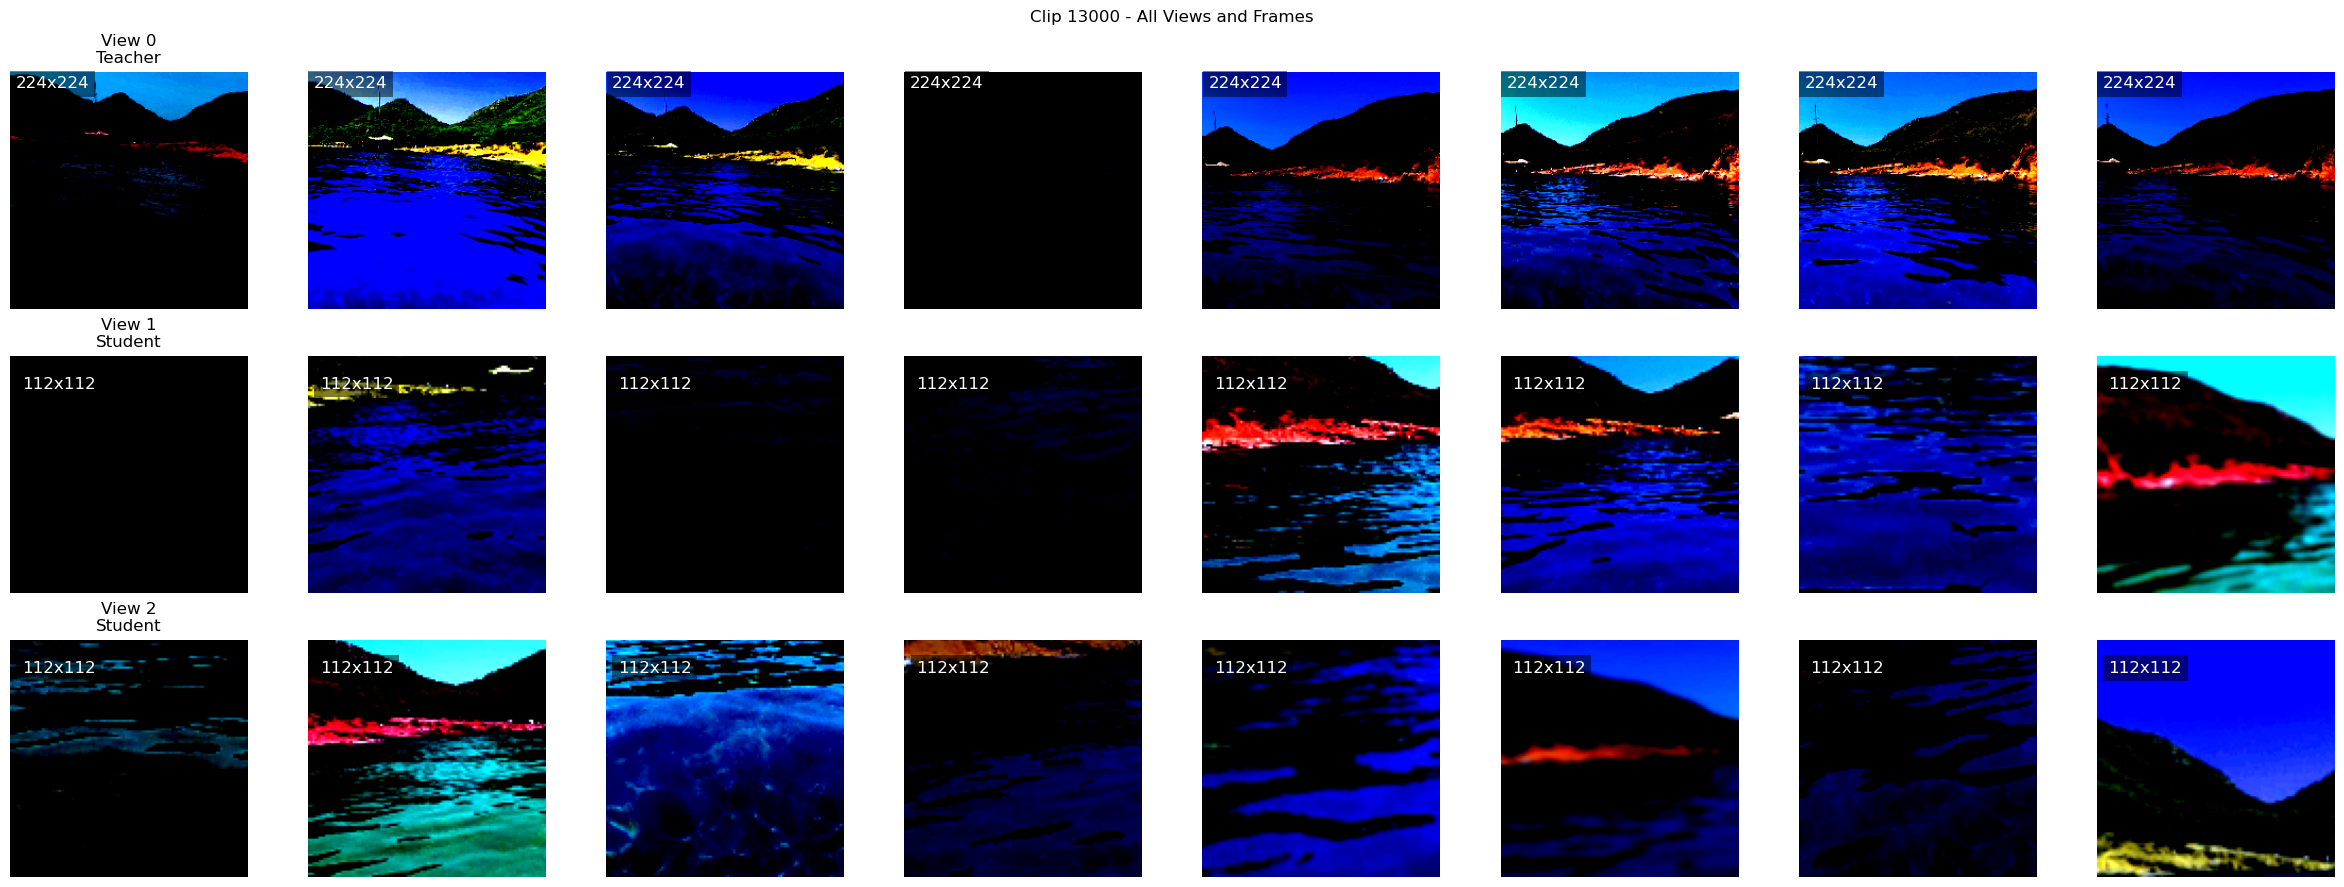

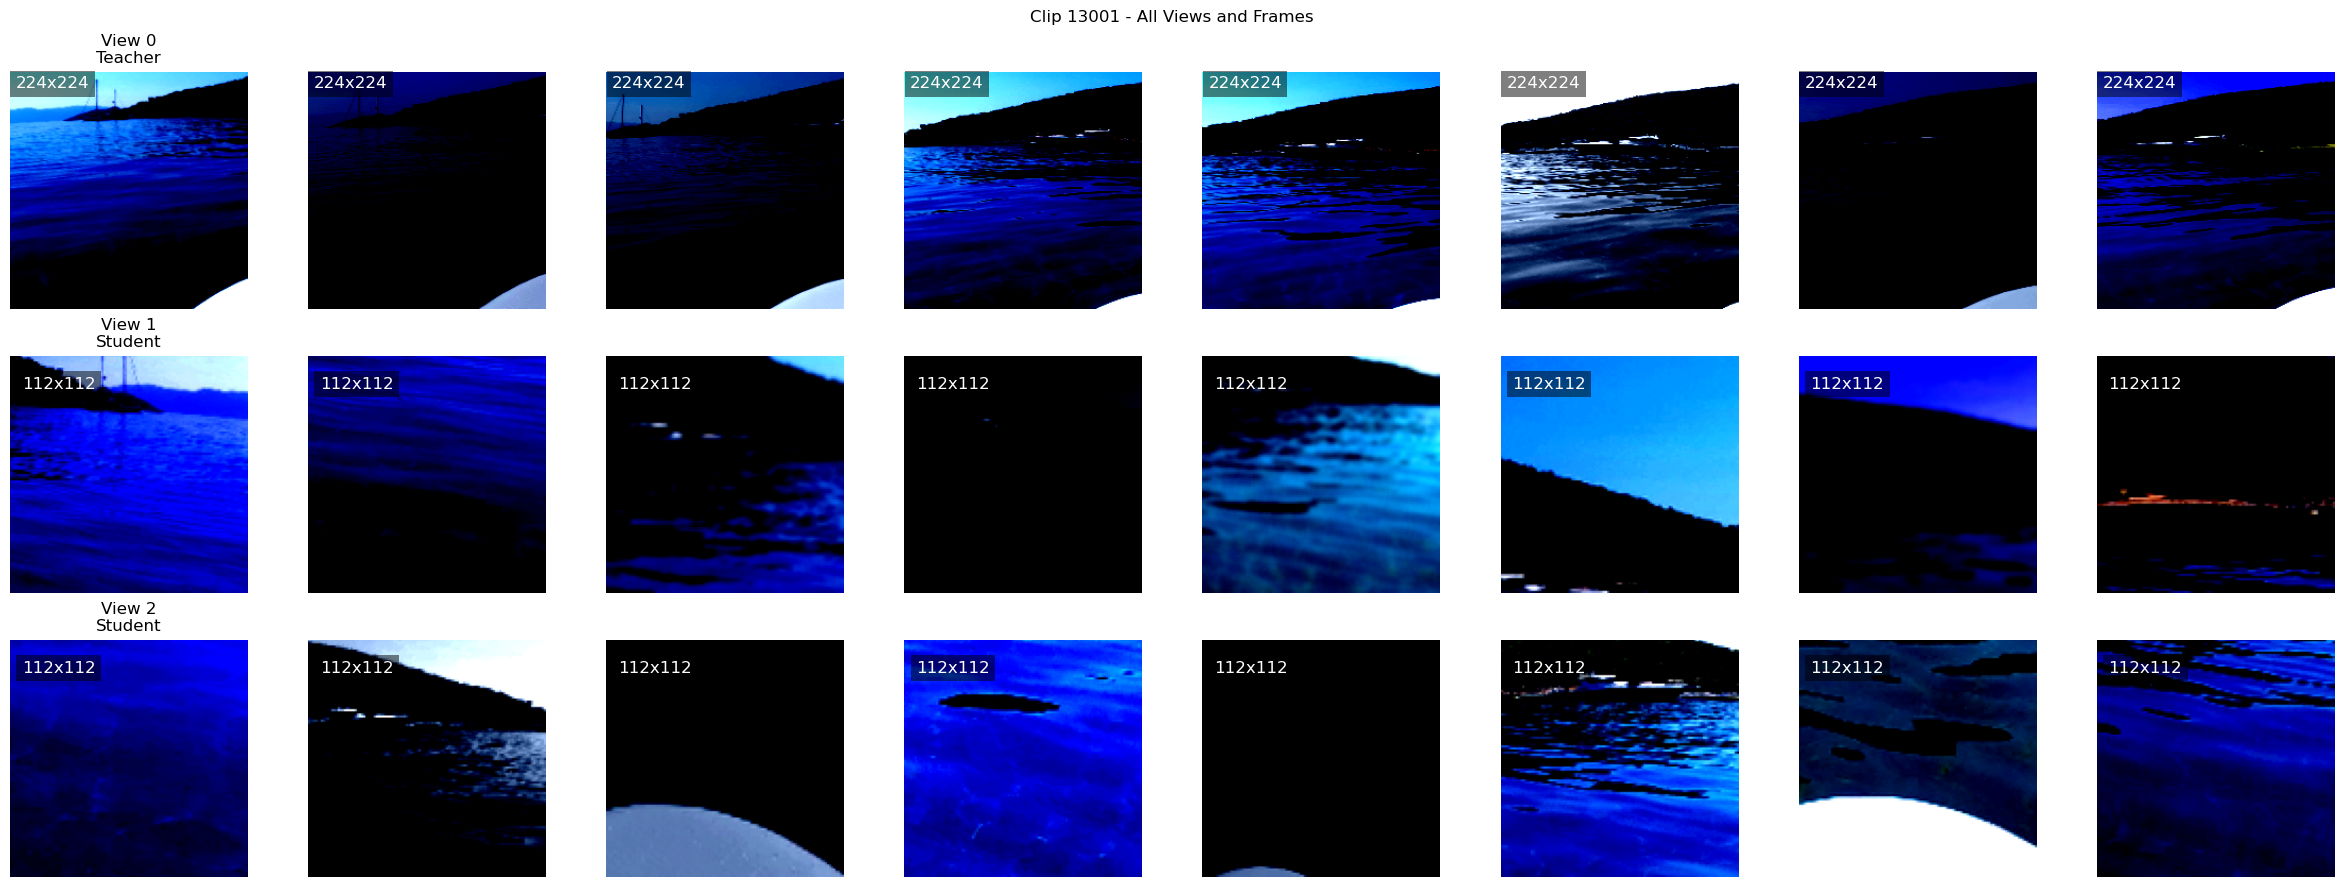

In [16]:
# "/media/giorgos/Win11/computer_vision_project/dataset.hdf5"

visualize_h5_clips("/home/giorgos/computer_vision/project/computer_vision_project/preprocessed_dataset/dataset.hdf5")

Total number of clips in dataset: 20970


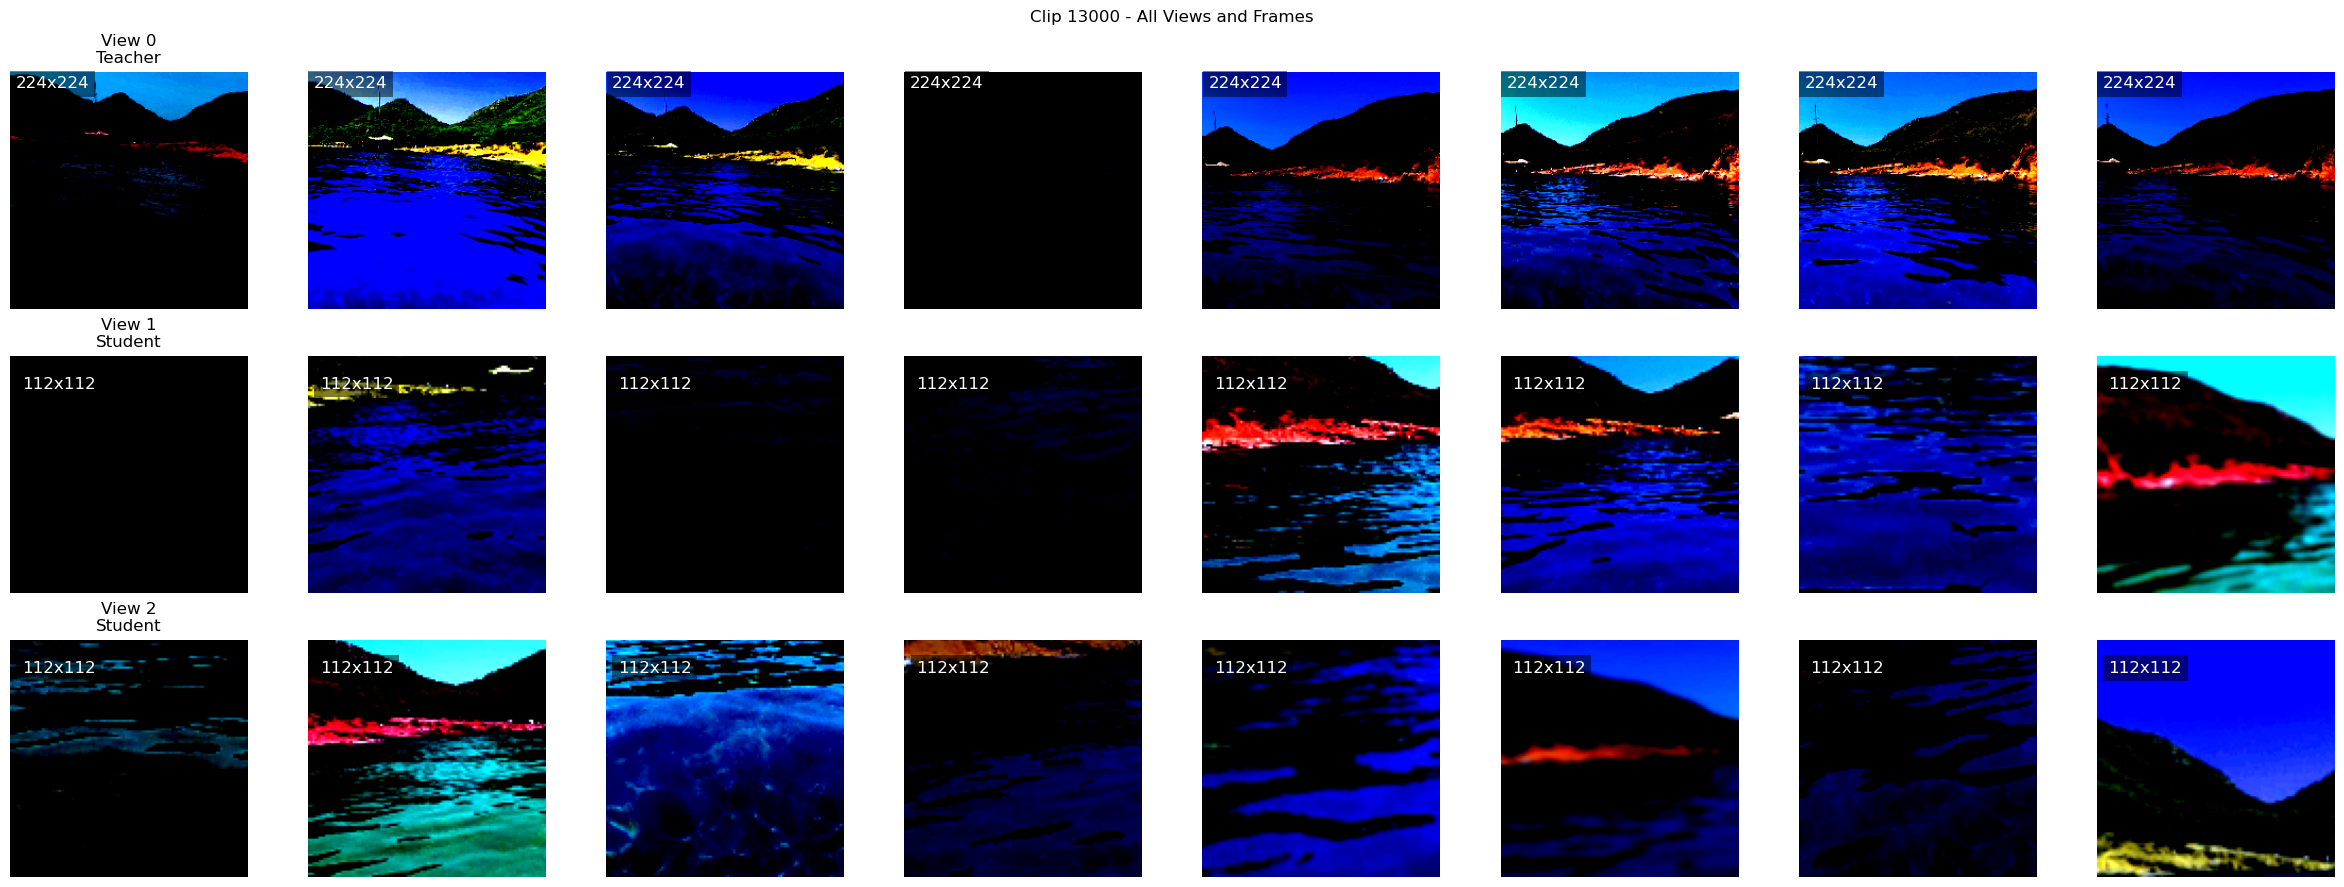

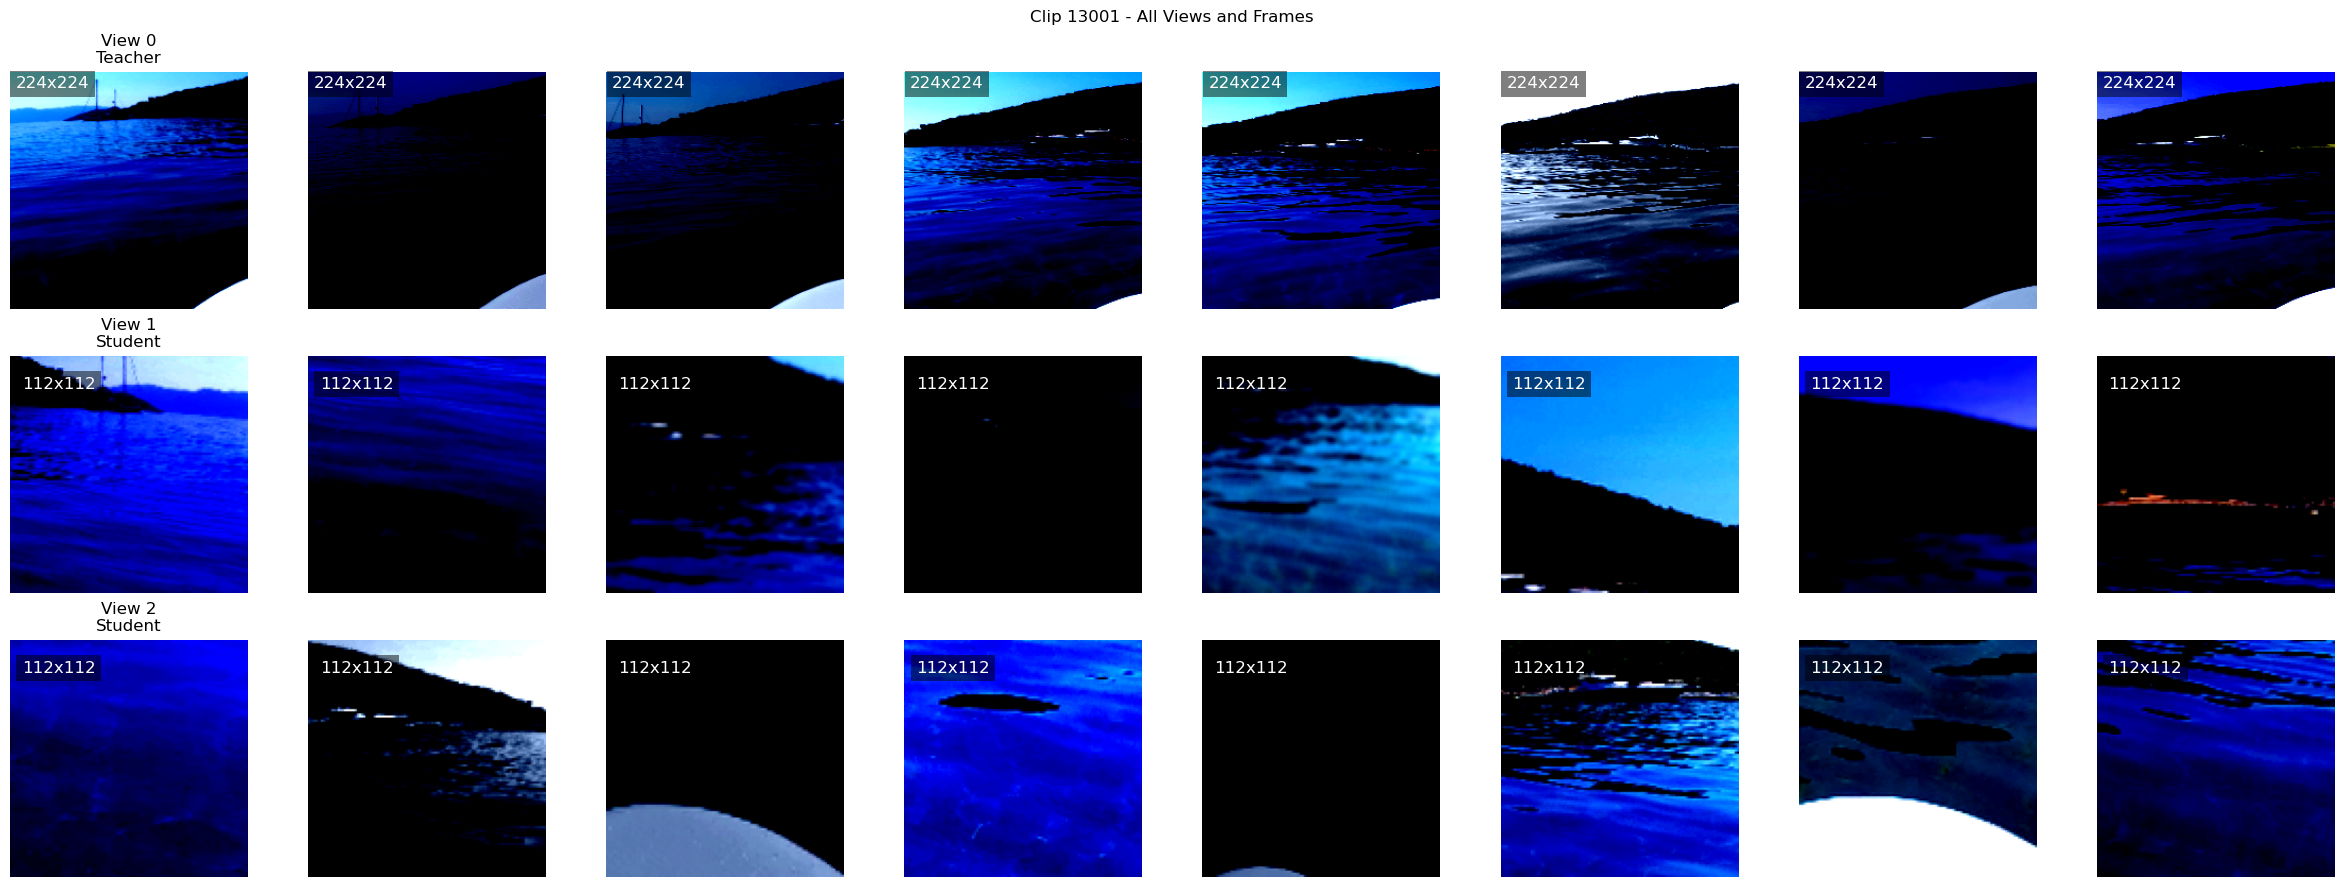

In [17]:
visualize_h5_clips("/home/giorgos/computer_vision/project/computer_vision_project/preprocessed_dataset/compressed_dataset.hdf5")

In [8]:
import h5py
import numpy as np
from tqdm import tqdm

def compress_hdf5_dataset(input_path: str, output_path: str, compression_level: int = 4):
    """
    Reopen an HDF5 dataset and save it to a new file with compression.
    
    Args:
        input_path (str): Path to the original HDF5 file
        output_path (str): Path where the compressed HDF5 file will be saved
        compression_level (int): GZIP compression level (1-9, default=9)
    """
    # Open the original file in read mode
    with h5py.File(input_path, 'r') as source:
        # Create new file with compression
        with h5py.File(output_path, 'w') as target:
            # Iterate through all groups
            for group_name in tqdm(source.keys(), desc="Processing groups"):
                # Create corresponding group in the target file
                target_group = target.create_group(group_name)
                
                # Copy all datasets within the group
                for dataset_name in source[group_name].keys():
                    # Read the original dataset
                    data = source[group_name][dataset_name][:]
                    
                    # Create compressed dataset in the target file
                    target_group.create_dataset(
                        name=dataset_name,
                        data=data,
                        compression='gzip',
                        compression_opts=compression_level
                    )
                    
                # Copy all attributes of the group
                for attr_name, attr_value in source[group_name].attrs.items():
                    target_group.attrs[attr_name] = attr_value

In [9]:
input_file = "/home/giorgos/computer_vision/project/computer_vision_project/preprocessed_dataset/dataset.hdf5"
output_file = "/home/giorgos/computer_vision/project/computer_vision_project/preprocessed_dataset/compressed_dataset.hdf5"

compress_hdf5_dataset(input_file, output_file)

# Print file sizes to verify compression
import os
original_size = os.path.getsize(input_file) / (1024 * 1024)  # MB
compressed_size = os.path.getsize(output_file) / (1024 * 1024)  # MB

print(f"\nOriginal file size: {original_size:.2f} MB")
print(f"Compressed file size: {compressed_size:.2f} MB")
print(f"Compression ratio: {original_size/compressed_size:.2f}x")

Processing groups: 100%|██████████| 20970/20970 [25:17<00:00, 13.82it/s]


Original file size: 144535.38 MB
Compressed file size: 40292.62 MB
Compression ratio: 3.59x
